In [20]:
import pandas as pd
import psycopg2

In [21]:
conn = psycopg2.connect(
    dbname="analyst_portfolio",
    user="pontus",
    password="",  
    host="localhost",
    port="5432"
)

In [22]:
query_active_users = """
SELECT
    month,
    COUNT(DISTINCT customer_id) AS active_users
FROM subscriptions
WHERE is_active = true
GROUP BY month
ORDER BY month;
"""

active_users = pd.read_sql(query_active_users, conn)
active_users['month'] = pd.to_datetime(active_users['month'])

/tmp/ipykernel_241653/654056775.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  active_users = pd.read_sql(query_active_users, conn)


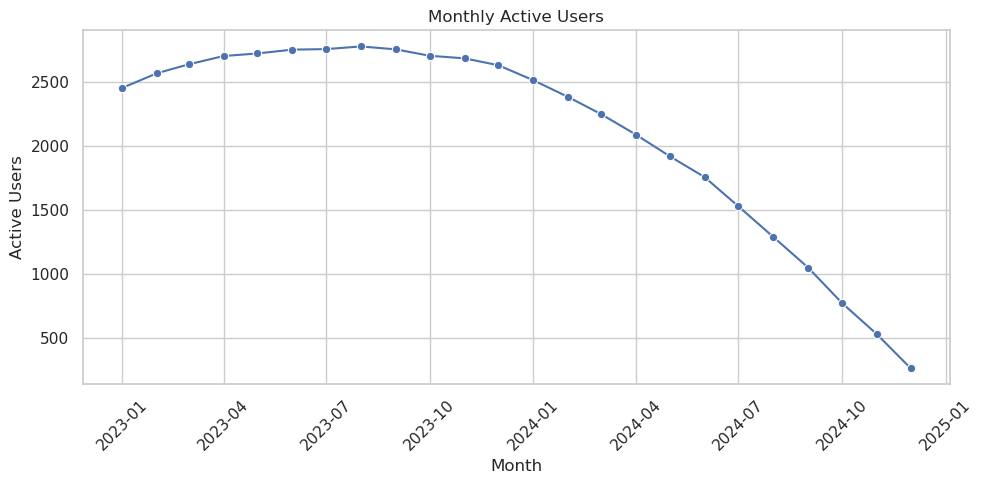

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(10,5))

sns.lineplot(data=active_users, x='month', y='active_users', marker='o')
plt.title("Monthly Active Users")
plt.xlabel("Month")
plt.ylabel("Active Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

You can see that there was a pretty steady but minor rise of monthly active users beginning in January 2023 that then started to peter out and fall beginning in around September 2023 and hitting an all time low in January 2025.

/tmp/ipykernel_241653/131184665.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  churn = pd.read_sql(churn_query, conn)


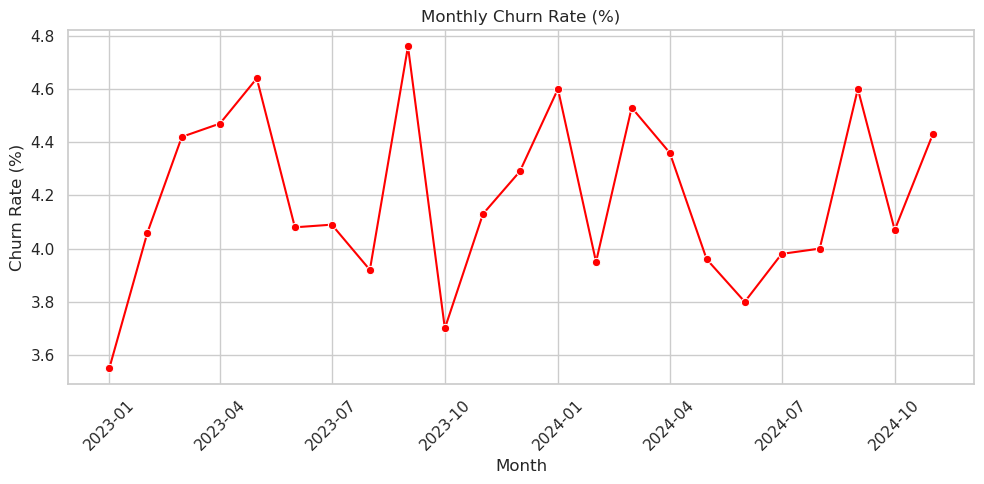

In [24]:
churn_query = "SELECT * FROM churn_flagged_view;"  # or the churn SQL query result
churn = pd.read_sql(churn_query, conn)
churn['month'] = pd.to_datetime(churn['month'])

plt.figure(figsize=(10,5))
sns.lineplot(data=churn, x='month', y='churn_rate_percent', marker='o', color='red')
plt.title("Monthly Churn Rate (%)")
plt.xlabel("Month")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The customer churn rate is somewhat uniform with frequent rises and falls, with the biggest time between rise and fall occuring between around March 2024 and September 2024.

/tmp/ipykernel_241653/4000436311.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  revenue_plan = pd.read_sql(revenue_plan_query, conn)


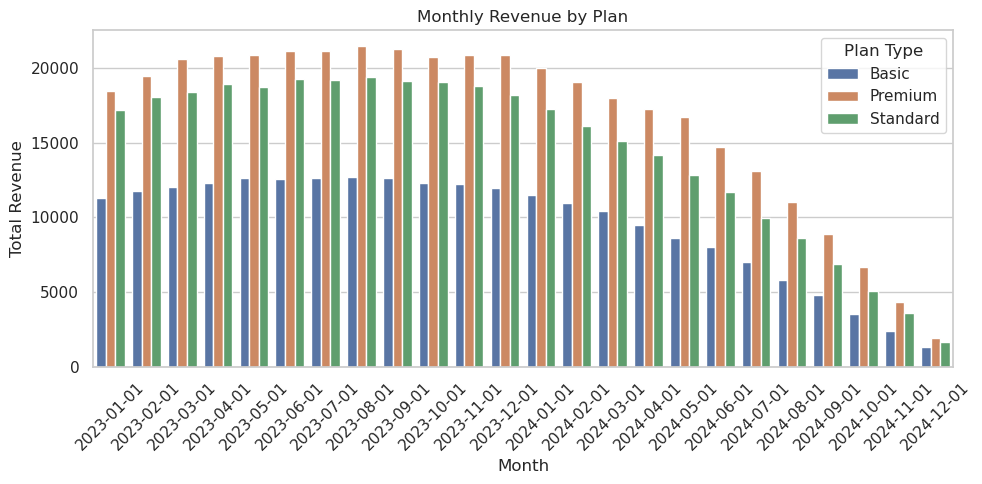

In [25]:
revenue_plan_query = "SELECT * FROM revenue_by_plan_view;"  # or export query result
revenue_plan = pd.read_sql(revenue_plan_query, conn)
revenue_plan['month'] = pd.to_datetime(revenue_plan['month'])

plt.figure(figsize=(10,5))
sns.barplot(
    data=revenue_plan,
    x='month',
    y='total_revenue',
    hue='plan_type'
)
plt.title("Monthly Revenue by Plan")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(title='Plan Type')
plt.tight_layout()
plt.show()


Premium and Standard are the two most revenue generating types of subscriptions with the Basic type falling behind by close to 50-60%.